# Analyzing Technology Adoption Patterns in Cameroonian Higher Education Using Data Mining

**Data Sources:**
- World Bank Open: Data  Cameroon ICT indicators (2000–2023)
- Student survey : 657 responses on AI usage and over-reliance behavior

**Tools:** Python, pandas, numpy, scikit-learn, matplotlib, seaborn, FastAPI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)


### World Bank Cameroon ICT Data (Secondary Data)

In [2]:
cel_raw = pd.read_csv('data/cameroon_mobile.csv', skiprows=4)
net_raw = pd.read_csv('data/cameroon_internet.csv', skiprows=4)

print('RAW WORLD BANK FILES ')
print(f'Mobile file    : {cel_raw.shape[0]} countries x {cel_raw.shape[1]} columns')
print(f'Internet file  : {net_raw.shape[0]} countries x {net_raw.shape[1]} columns')
print()
print('Indicators:')
print(' Mobile   :', cel_raw['Indicator Name'].iloc[0])
print(' Internet :', net_raw['Indicator Name'].iloc[0])
print()
year_cols = [c for c in cel_raw.columns if c.isdigit()]
print(f'Year columns available: {year_cols[0]} to {year_cols[-1]} ({len(year_cols)} years total)')

RAW WORLD BANK FILES 
Mobile file    : 266 countries x 71 columns
Internet file  : 266 countries x 71 columns

Indicators:
 Mobile   : Mobile cellular subscriptions (per 100 people)
 Internet : Individuals using the Internet (% of population)

Year columns available: 1960 to 2025 (66 years total)


### Student Survey Data (Primary Data)


In [3]:
survey_raw = pd.read_csv('data/survey_responses_synthetic.csv')

print('RAW SURVEY DATA')
print(f'Shape          : {survey_raw.shape[0]} responses x {survey_raw.shape[1]} columns')
print(f'Missing values : {survey_raw.isnull().sum().sum()}')
print(f'Duplicate rows : {survey_raw.duplicated().sum()}')
print()
print('Columns:')
for i, col in enumerate(survey_raw.columns, 1):
    print(f'  {i:2d}. {col}')

RAW SURVEY DATA
Shape          : 657 responses x 15 columns
Missing values : 0
Duplicate rows : 0

Columns:
   1. Timestamp
   2. What region do you attend university
   3. What is your field of study?
   4. What academic level are you at?
   5. What is your gender?
   6. How many AI tools do you use regularly? (ChatGPT, Gemini, Claude, Copilot, etc.)
   7. How many hours per day do you spend using AI tools?
   8. For which academic tasks do you use AI? (select all that apply)
   9. How often do you verify what an AI tool tells you before using it?
  10. How confident are you completing academic tasks without AI?
  11. Have you submitted AI-generated content as your own work without major edits?
  12. Do you feel anxious or stuck when AI tools are unavailable?
  13. How much do you trust AI output without checking the source?
  14. How well do you understand the limitations of AI tools?
  15. Has your university given any guidance on responsible AI use?


## Data Preparation

In [4]:
print('ICT DATA')

# Step 1: Filter Cameroon only
print(f'Step 1 — Raw data loaded           : {len(cel_raw)} countries')
cel_cm = cel_raw[cel_raw['Country Code'] == 'CMR']
net_cm = net_raw[net_raw['Country Code'] == 'CMR']
print(f'Step 2 — Filter Cameroon (CMR)     : 1 country  (removed {len(cel_raw)-1})')

# Step 3: Extract years 2000-2023
years = [str(y) for y in range(2000, 2024)]
mob_df = cel_cm[years].T.reset_index()
net_df = net_cm[years].T.reset_index()
mob_df.columns = ['year', 'mobile_per100']
net_df.columns = ['year', 'internet_pct']
mob_df['year'] = mob_df['year'].astype(int)
net_df['year'] = net_df['year'].astype(int)
print(f'Step 3 — Extract years 2000–2023   : {len(mob_df)} rows')

# Step 4: Merge both indicators
ict_raw = pd.merge(mob_df, net_df, on='year')
print(f'Step 4 — Merge mobile + internet   : {len(ict_raw)} rows')

# Step 5: Drop nulls
before = len(ict_raw)
ict = ict_raw.dropna().copy()
print(f'Step 5 — Drop null values          : {len(ict)} rows  (removed {before - len(ict)})')

# Step 6: Add year_index feature
ict['year_index'] = ict['year'] - ict['year'].min()
print(f'Step 6 — Add year_index column     : {len(ict)} rows  (no rows removed)')

# Step 7: Compute ICT adoption score (0-100)
# Internet gets 60% weight — more directly linked to AI tool access
# Mobile gets 40% weight
mob_norm = (ict['mobile_per100'] - ict['mobile_per100'].min()) / (ict['mobile_per100'].max() - ict['mobile_per100'].min())
net_norm = (ict['internet_pct'] - ict['internet_pct'].min()) / (ict['internet_pct'].max() - ict['internet_pct'].min())
ict['ict_score'] = ((mob_norm * 0.4 + net_norm * 0.6) * 100).round(2)
print(f'Step 7 — Compute ICT adoption score: {len(ict)} rows  (no rows removed)')

print()
print(f'FINAL ICT DATASET: {ict.shape[0]} rows x {ict.shape[1]} columns')
print()
print(ict.to_string(index=False))

ICT DATA
Step 1 — Raw data loaded           : 266 countries
Step 2 — Filter Cameroon (CMR)     : 1 country  (removed 265)
Step 3 — Extract years 2000–2023   : 24 rows
Step 4 — Merge mobile + internet   : 24 rows
Step 5 — Drop null values          : 24 rows  (removed 0)
Step 6 — Add year_index column     : 24 rows  (no rows removed)
Step 7 — Compute ICT adoption score: 24 rows  (no rows removed)

FINAL ICT DATASET: 24 rows x 5 columns

 year  mobile_per100  internet_pct  year_index  ict_score
 2000       0.692561      0.252120           0       0.00
 2001       2.725728      0.277051           1       0.88
 2002       4.460944      0.360872           2       1.73
 2003       6.664464      0.587623           3       2.97
 2004       9.216274      0.976075           4       4.59
 2005      13.192161      1.402700           5       6.86
 2006      17.868224      2.028700           6       9.71
 2007      25.130339      2.930000           7      14.03
 2008      33.169347      3.400000     

In [5]:
print('SURVEY DATA')


step = survey_raw.copy()
print(f'Step 1 — Raw data loaded           : {len(step)} rows')

# Step 2: Rename columns
step.columns = [
    'timestamp','region','field_of_study','academic_level','gender',
    'ai_tools_count','daily_ai_hours','ai_tasks',
    'verify_ai_output','confidence_without_ai','submitted_ai_content',
    'anxiety_without_ai','trust_without_check','ai_literacy','university_guidance'
]
print(f'Step 2 — Rename columns            : {len(step)} rows  (no rows removed)')

# Step 3: Remove duplicates
before = len(step)
step = step.drop_duplicates()
print(f'Step 3 — Remove duplicates         : {len(step)} rows  (removed {before - len(step)})')

# Step 4: Drop null values
before = len(step)
step = step.dropna()
print(f'Step 4 — Drop null values          : {len(step)} rows  (removed {before - len(step)})')

# Step 5: Encode categorical columns to numeric
hours_map     = {'Less than 1hr': 1, '1-2hrs': 2, '3-4hrs': 3, '5hrs or more': 4}
tools_map     = {'0': 0, '1': 1, '2': 2, '3': 3, '4 or more': 4}
submitted_map = {'Never': 0, 'Once or twice': 1, 'Sometimes': 2, 'Often': 3}
guidance_map  = {'yes': 1, 'no': 0, 'not sure': 0}

step = step.copy()
step['hours_num']     = step['daily_ai_hours'].map(hours_map)
step['tools_num']     = step['ai_tools_count'].map(tools_map)
step['submitted_num'] = step['submitted_ai_content'].map(submitted_map)
step['guidance_num']  = step['university_guidance'].map(guidance_map)

before = len(step)
step = step.dropna(subset=['hours_num','tools_num','submitted_num','guidance_num'])
print(f'Step 5 — Encode categorical columns: {len(step)} rows  (removed {before - len(step)})')

# Step 6: Compute risk score
raw_risk = (
    step['hours_num'] * 8
    + (6 - step['verify_ai_output']) * 7
    + (6 - step['confidence_without_ai']) * 6
    + step['submitted_num'] * 6
    + step['anxiety_without_ai'] * 5
    + step['trust_without_check'] * 4
)
raw_norm = (raw_risk - raw_risk.min()) / (raw_risk.max() - raw_risk.min()) * 100
step['risk_score'] = raw_norm.round(2)
step['risk_level'] = raw_norm.apply(lambda s: 'Low' if s < 33 else ('Medium' if s < 66 else 'High'))
print(f'Step 6 — Compute risk score        : {len(step)} rows  (no rows removed)')

survey = step.copy()
print()
print(f'FINAL SURVEY DATASET: {survey.shape[0]} rows x {survey.shape[1]} columns')
print()
print('Risk level distribution:')
for level, count in survey['risk_level'].value_counts().items():
    bar = '#' * int(count / 3)
    print(f'  {level:<8}: {count:>3} students ({count/len(survey)*100:.1f}%)  {bar}')

SURVEY DATA
Step 1 — Raw data loaded           : 657 rows
Step 2 — Rename columns            : 657 rows  (no rows removed)
Step 3 — Remove duplicates         : 657 rows  (removed 0)
Step 4 — Drop null values          : 657 rows  (removed 0)
Step 5 — Encode categorical columns: 657 rows  (removed 0)
Step 6 — Compute risk score        : 657 rows  (no rows removed)

FINAL SURVEY DATASET: 657 rows x 21 columns

Risk level distribution:
  Medium  : 413 students (62.9%)  #########################################################################################################################################
  Low     : 182 students (27.7%)  ############################################################
  High    :  62 students (9.4%)  ####################


###  Summary

In [6]:
print('ICT DATASET  STATISTICAL SUMMARY')
print(ict[['mobile_per100','internet_pct','ict_score']].describe().round(2))
print()
print('SURVEY DATASET  NUMERICAL FEATURES SUMMARY')
num_cols = ['verify_ai_output','confidence_without_ai','anxiety_without_ai',
            'trust_without_check','ai_literacy','risk_score']
print(survey[num_cols].describe().round(2))

ICT DATASET  STATISTICAL SUMMARY
       mobile_per100  internet_pct  ict_score
count          24.00         24.00      24.00
mean           50.75         14.43      41.16
std            33.42         15.25      34.55
min             0.69          0.25       0.00
25%            16.70          1.87       9.00
50%            57.41          6.25      32.25
75%            80.06         24.83      68.73
max            96.48         42.24     100.00

SURVEY DATASET  NUMERICAL FEATURES SUMMARY
       verify_ai_output  confidence_without_ai  anxiety_without_ai  \
count            657.00                 657.00              657.00   
mean               3.39                   2.62                3.21   
std                1.19                   1.26                1.21   
min                1.00                   1.00                1.00   
25%                3.00                   2.00                2.00   
50%                3.00                   2.00                3.00   
75%                


## Exploratory Data Analysis (EDA)

### ICT Adoption Trends in Cameroon

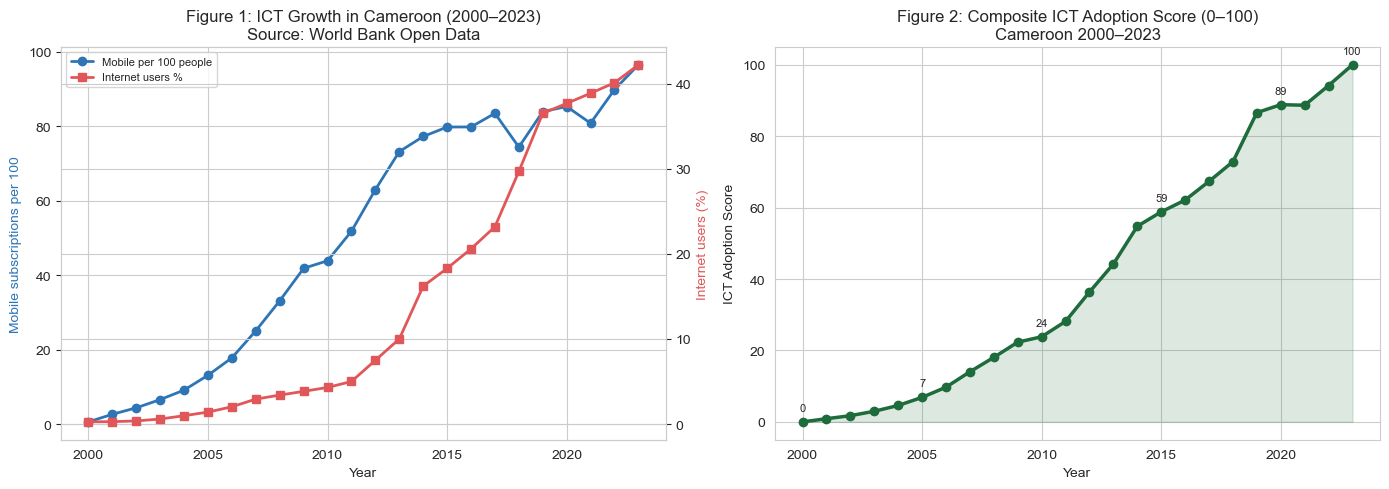

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Dual axis — mobile and internet trends
ax2 = axes[0].twinx()
axes[0].plot(ict['year'], ict['mobile_per100'], color='#2E75B6', marker='o', linewidth=2, label='Mobile per 100 people')
ax2.plot(ict['year'], ict['internet_pct'], color='#E15759', marker='s', linewidth=2, label='Internet users %')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mobile subscriptions per 100', color='#2E75B6')
ax2.set_ylabel('Internet users (%)', color='#E15759')
axes[0].set_title('Figure 1: ICT Growth in Cameroon (2000–2023)\nSource: World Bank Open Data')
l1, lb1 = axes[0].get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
axes[0].legend(l1+l2, lb1+lb2, loc='upper left', fontsize=8)

# Chart 2: ICT adoption score
axes[1].plot(ict['year'], ict['ict_score'], color='#1E6B3C', linewidth=2.5, marker='o')
axes[1].fill_between(ict['year'], ict['ict_score'], alpha=0.15, color='#1E6B3C')
for _, row in ict.iterrows():
    if row['year'] in [2000, 2005, 2010, 2015, 2020, 2023]:
        axes[1].annotate(f"{row['ict_score']:.0f}", (row['year'], row['ict_score']),
                         textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
axes[1].set_title('Figure 2: Composite ICT Adoption Score (0–100)\nCameroon 2000–2023')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('ICT Adoption Score')

plt.tight_layout()
plt.savefig('plots/fig1_fig2_ict_trends.png', bbox_inches='tight')
plt.show()


In [8]:
print('Observation: ICT adoption grew steadily from near zero in 2000 to 100 by 2023.')
print('Internet access (60% weight) drove the score more than mobile subscriptions.')

Observation: ICT adoption grew steadily from near zero in 2000 to 100 by 2023.
Internet access (60% weight) drove the score more than mobile subscriptions.


### Survey Data 

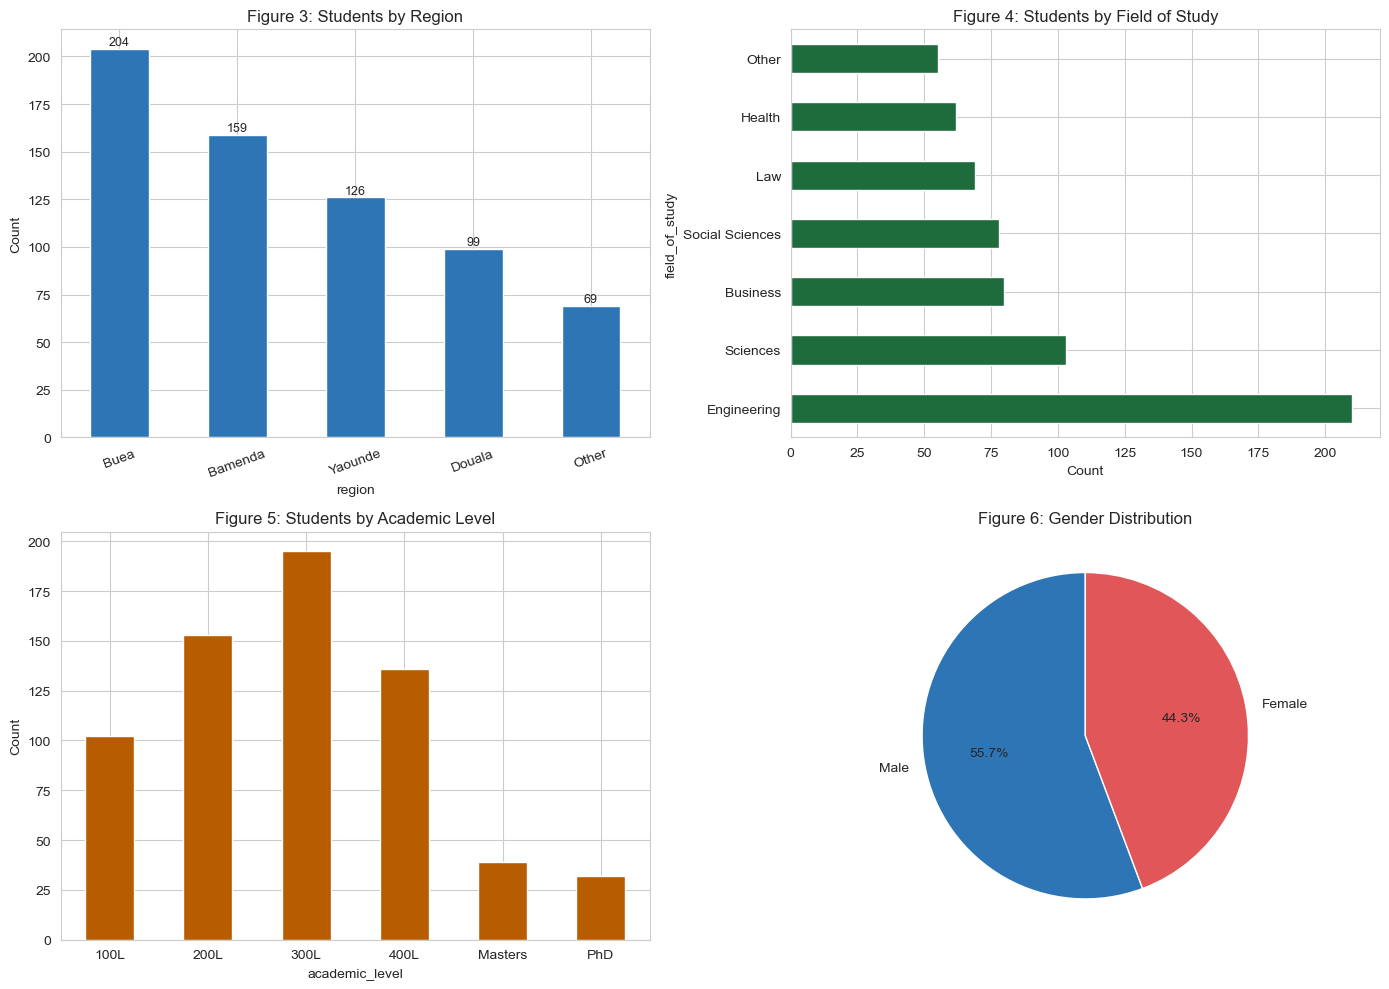

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Region distribution
survey['region'].value_counts().plot(kind='bar', ax=axes[0,0], color='#2E75B6', edgecolor='white', rot=20)
axes[0,0].set_title('Figure 3: Students by Region')
axes[0,0].set_ylabel('Count')
for bar in axes[0,0].patches:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, int(bar.get_height()), ha='center', fontsize=9)

# Field of study
survey['field_of_study'].value_counts().plot(kind='barh', ax=axes[0,1], color='#1E6B3C', edgecolor='white')
axes[0,1].set_title('Figure 4: Students by Field of Study')
axes[0,1].set_xlabel('Count')

# Academic level
level_order = ['100L','200L','300L','400L','Masters','PhD']
level_counts = survey['academic_level'].value_counts().reindex(level_order, fill_value=0)
level_counts.plot(kind='bar', ax=axes[1,0], color='#B85C00', edgecolor='white', rot=0)
axes[1,0].set_title('Figure 5: Students by Academic Level')
axes[1,0].set_ylabel('Count')

# Gender
survey['gender'].value_counts().plot(kind='pie', ax=axes[1,1],
    colors=['#2E75B6','#E15759'], autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Figure 6: Gender Distribution')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.savefig('plots/fig3_fig6_demographics.png', bbox_inches='tight')
plt.show()

### AI Usage and Risk Distributions

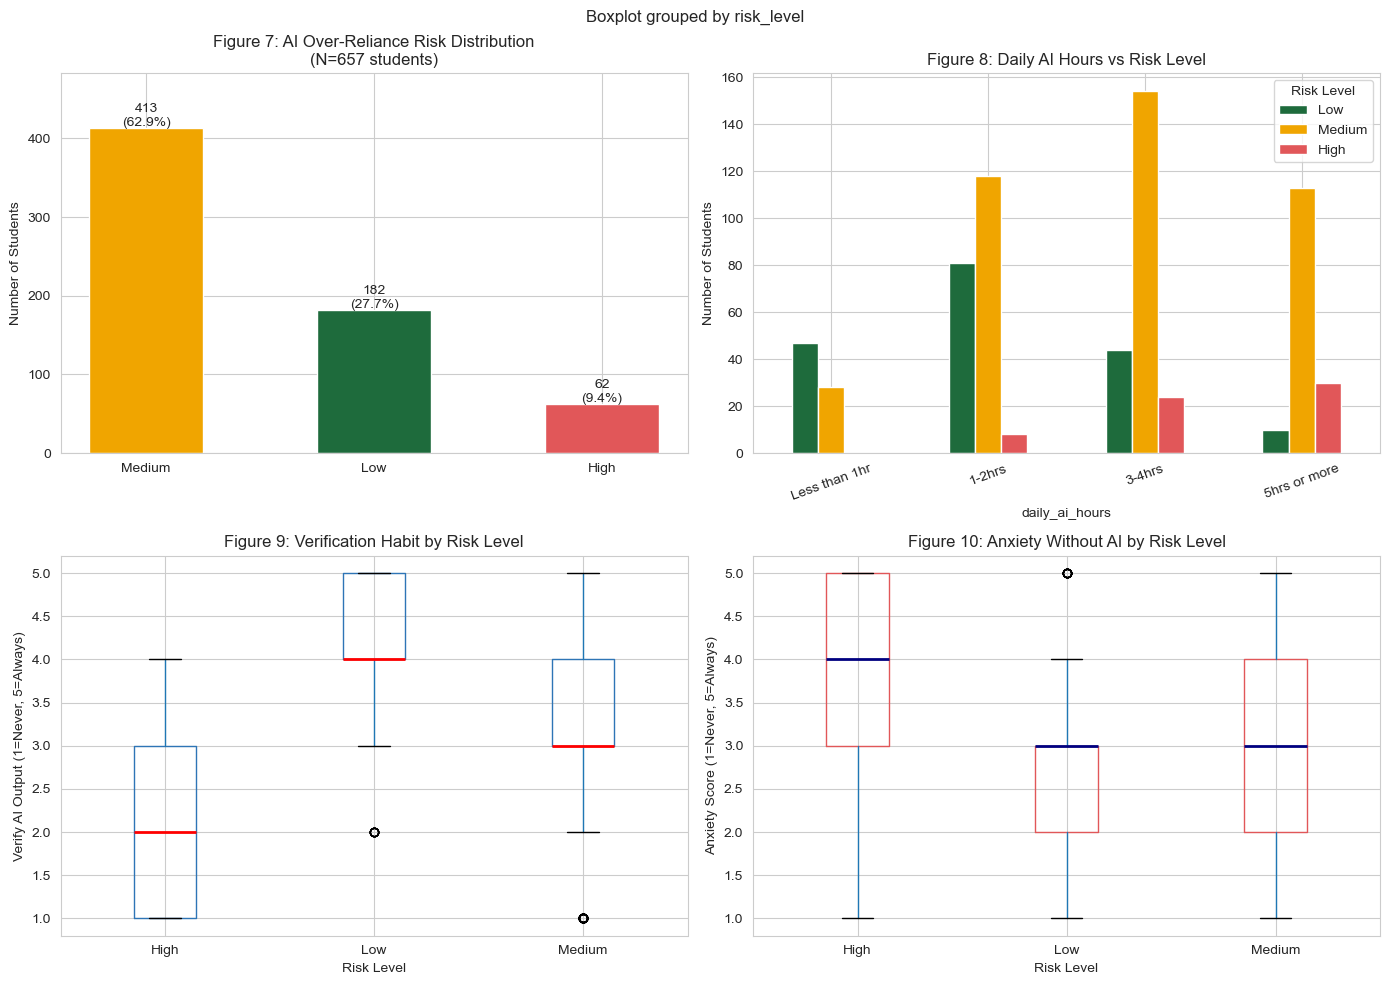

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

risk_colors = {'Low':'#1E6B3C','Medium':'#F0A500','High':'#E15759'}

# Risk level distribution
counts = survey['risk_level'].value_counts()
bars = axes[0,0].bar(counts.index, counts.values,
    color=[risk_colors[k] for k in counts.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
        f'{val}\n({val/len(survey)*100:.1f}%)', ha='center', fontsize=10)
axes[0,0].set_title(f'Figure 7: AI Over-Reliance Risk Distribution\n(N={len(survey)} students)')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].set_ylim(0, counts.max()+70)

# Daily AI hours by risk level
hours_order = ['Less than 1hr','1-2hrs','3-4hrs','5hrs or more']
risk_order  = ['Low','Medium','High']
ct = pd.crosstab(survey['daily_ai_hours'], survey['risk_level']).reindex(hours_order).fillna(0)
ct[risk_order].plot(kind='bar', ax=axes[0,1],
    color=['#1E6B3C','#F0A500','#E15759'], edgecolor='white', rot=20)
axes[0,1].set_title('Figure 8: Daily AI Hours vs Risk Level')
axes[0,1].set_ylabel('Number of Students')
axes[0,1].legend(title='Risk Level')

# Boxplot — verify_ai_output by risk level (as taught in Unit 1)
survey.boxplot(column='verify_ai_output', by='risk_level', ax=axes[1,0],
    boxprops=dict(color='#2E75B6'), medianprops=dict(color='red', linewidth=2))
axes[1,0].set_title('Figure 9: Verification Habit by Risk Level')
axes[1,0].set_xlabel('Risk Level')
axes[1,0].set_ylabel('Verify AI Output (1=Never, 5=Always)')
plt.sca(axes[1,0])
plt.title('Figure 9: Verification Habit by Risk Level')

# Boxplot — anxiety by risk level
survey.boxplot(column='anxiety_without_ai', by='risk_level', ax=axes[1,1],
    boxprops=dict(color='#E15759'), medianprops=dict(color='navy', linewidth=2))
axes[1,1].set_title('Figure 10: Anxiety Without AI by Risk Level')
axes[1,1].set_xlabel('Risk Level')
axes[1,1].set_ylabel('Anxiety Score (1=Never, 5=Always)')
plt.sca(axes[1,1])
plt.title('Figure 10: Anxiety Without AI by Risk Level')

plt.tight_layout()
plt.savefig('plots/fig7_fig10_risk_analysis.png', bbox_inches='tight')
plt.show()

###  Correlation Analysis

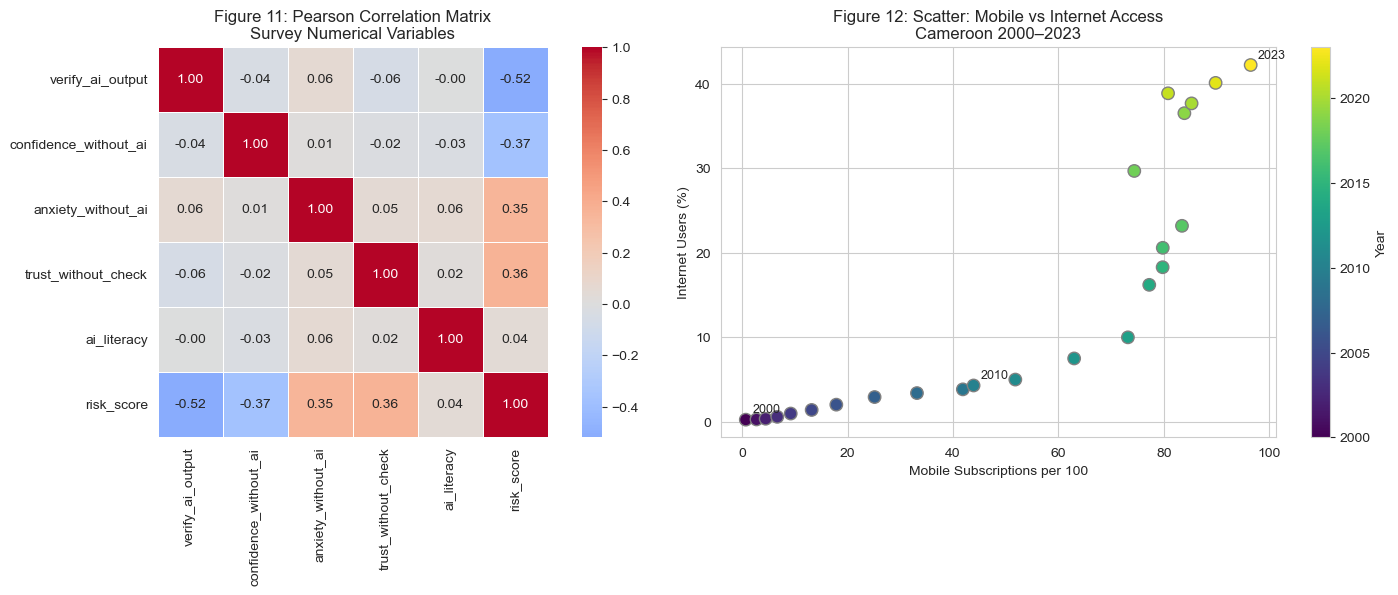

Key Pearson correlations with risk_score:
  verify_ai_output            : r =  -0.52  (negative)
  confidence_without_ai       : r =  -0.37  (negative)
  anxiety_without_ai          : r =   0.35  (positive)
  trust_without_check         : r =   0.36  (positive)
  ai_literacy                 : r =   0.04  (positive)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap — survey numerical features
num_cols = ['verify_ai_output','confidence_without_ai','anxiety_without_ai',
            'trust_without_check','ai_literacy','risk_score']
corr = survey[num_cols].corr().round(2)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=axes[0])
axes[0].set_title('Figure 11: Pearson Correlation Matrix\nSurvey Numerical Variables')

# Scatter — ICT data: mobile vs internet
scatter = axes[1].scatter(ict['mobile_per100'], ict['internet_pct'],
    c=ict['year'], cmap='viridis', s=80, edgecolors='grey')
plt.colorbar(scatter, ax=axes[1], label='Year')
for _, row in ict.iterrows():
    if row['year'] in [2000, 2010, 2023]:
        axes[1].annotate(str(int(row['year'])),
            (row['mobile_per100'], row['internet_pct']),
            textcoords='offset points', xytext=(5,5), fontsize=9)
axes[1].set_xlabel('Mobile Subscriptions per 100')
axes[1].set_ylabel('Internet Users (%)')
axes[1].set_title('Figure 12: Scatter: Mobile vs Internet Access\nCameroon 2000–2023')

plt.tight_layout()
plt.savefig('plots/fig11_fig12_correlation.png', bbox_inches='tight')
plt.show()

# Print Pearson r for key pairs
print('Key Pearson correlations with risk_score:')
for col in num_cols[:-1]:
    r = corr.loc[col, 'risk_score']
    direction = 'positive' if r > 0 else 'negative'
    print(f'  {col:<28}: r = {r:>6.2f}  ({direction})')

###  Histogram Analysis

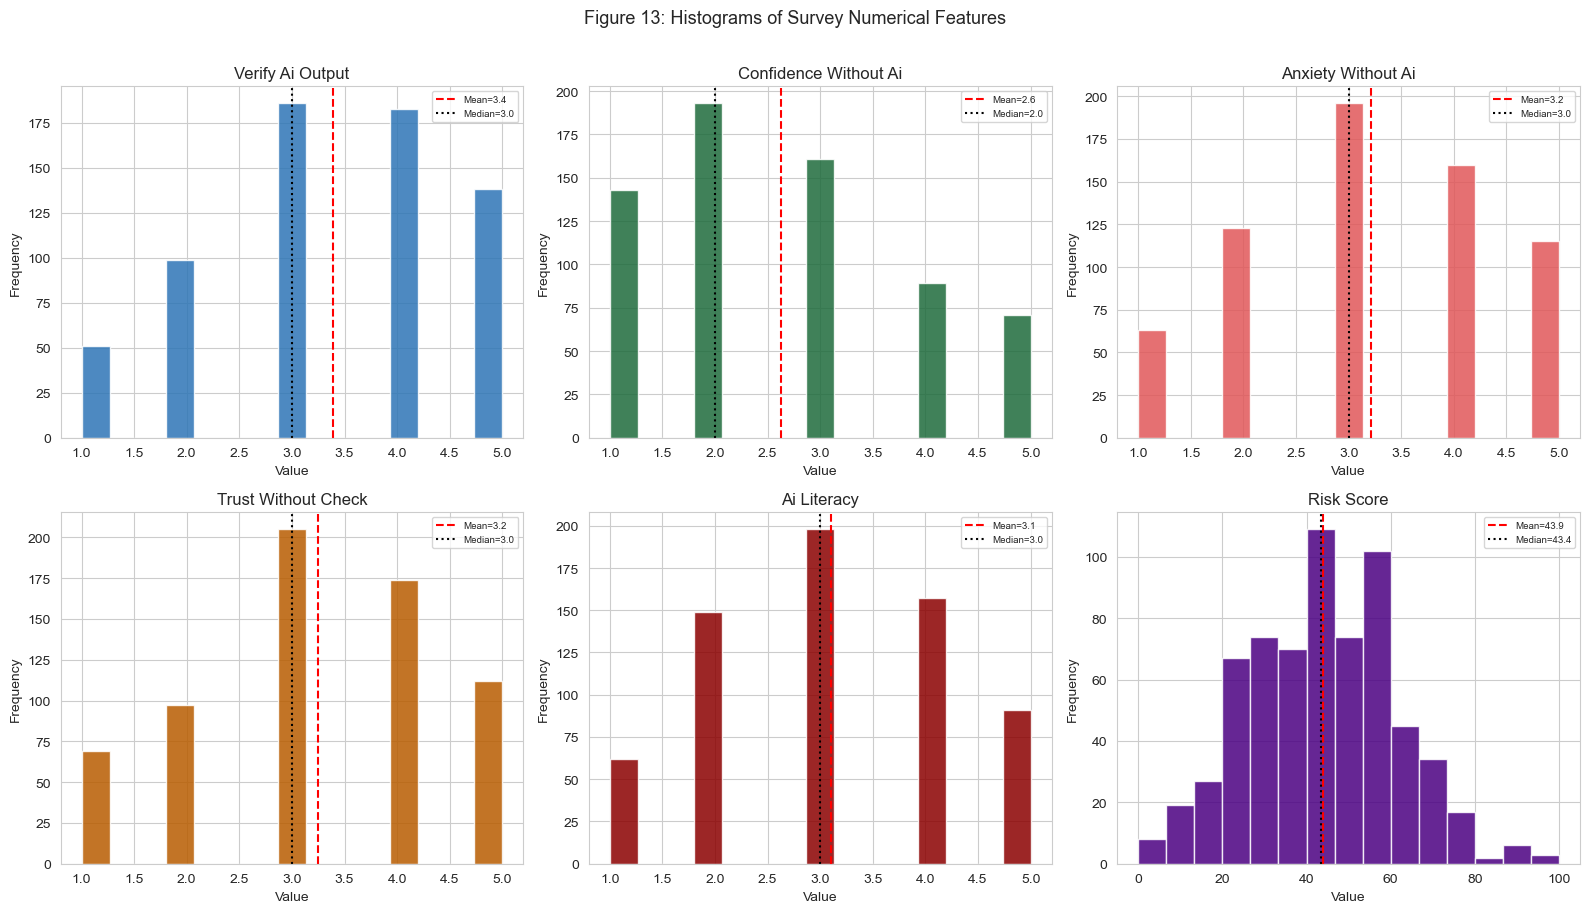

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_to_plot = ['verify_ai_output','confidence_without_ai','anxiety_without_ai',
                'trust_without_check','ai_literacy','risk_score']
colors = ['#2E75B6','#1E6B3C','#E15759','#B85C00','#8B0000','#4B0082']

for ax, col, color in zip(axes.flatten(), cols_to_plot, colors):
    ax.hist(survey[col], bins=15, color=color, edgecolor='white', alpha=0.85)
    mean_val = survey[col].mean()
    median_val = survey[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.1f}')
    ax.axvline(median_val, color='black', linestyle=':', linewidth=1.5, label=f'Median={median_val:.1f}')
    ax.set_title(col.replace('_',' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)

plt.suptitle('Figure 13: Histograms of Survey Numerical Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/fig13_histograms.png', bbox_inches='tight')
plt.show()


##  Train / Test Split


In [13]:
# ICT split (for Linear Regression) 
X_ict = ict[['year_index','mobile_per100','internet_pct']]
y_ict = ict['ict_score']

X_ict_train, X_ict_test, y_ict_train, y_ict_test = train_test_split(
    X_ict, y_ict, test_size=0.20, random_state=42)

print('ICT SPLIT')
print(f'  Total   : {len(X_ict)} rows')
print(f'  Train   : {len(X_ict_train)} rows (80%)')
print(f'  Test    : {len(X_ict_test)} rows (20%)')
print()

# --- Survey split (for Classification) ---
features = ['tools_num','hours_num','verify_ai_output','confidence_without_ai',
            'submitted_num','anxiety_without_ai','trust_without_check',
            'ai_literacy','guidance_num']

X_sur = survey[features]
y_sur = survey['risk_level']

le = LabelEncoder()
y_enc = le.fit_transform(y_sur)

X_sur_train, X_sur_test, y_sur_train, y_sur_test = train_test_split(
    X_sur, y_enc, test_size=0.20, random_state=42, stratify=y_enc)

# Scale for KNN
scaler = StandardScaler()
X_sur_train_s = scaler.fit_transform(X_sur_train)
X_sur_test_s  = scaler.transform(X_sur_test)

print('SURVEY SPLIT')
print(f'  Total   : {len(X_sur)} rows')
print(f'  Train   : {len(X_sur_train)} rows (80%)')
print(f'  Test    : {len(X_sur_test)} rows (20%)')
print(f'  Classes : {list(le.classes_)}')
print()
print('Class distribution in training set:')
for cls, enc in zip(le.classes_, range(len(le.classes_))):
    count = (y_sur_train == enc).sum()
    print(f'  {cls}: {count} ({count/len(y_sur_train)*100:.1f}%)')

# Clustering features (no labels needed)
X_clust = X_sur.values
X_clust_s = scaler.fit_transform(X_clust)

ICT SPLIT
  Total   : 24 rows
  Train   : 19 rows (80%)
  Test    : 5 rows (20%)

SURVEY SPLIT
  Total   : 657 rows
  Train   : 525 rows (80%)
  Test    : 132 rows (20%)
  Classes : ['High', 'Low', 'Medium']

Class distribution in training set:
  High: 50 (9.5%)
  Low: 145 (27.6%)
  Medium: 330 (62.9%)



##  Model 1: Linear Regression

In [14]:
lr = LinearRegression()
lr.fit(X_ict_train, y_ict_train)
y_ict_pred = lr.predict(X_ict_test)

mae  = mean_absolute_error(y_ict_test, y_ict_pred)
rmse = np.sqrt(mean_squared_error(y_ict_test, y_ict_pred))
r2   = r2_score(y_ict_test, y_ict_pred)

print('LINEAR REGRESSION — RESULTS')
print(f'Training samples  : {len(X_ict_train)}')
print(f'Testing samples   : {len(X_ict_test)}')
print()
print(f'MAE   (Mean Absolute Error)  : {mae:.4f}')
print(f'RMSE  (Root Mean Sq. Error)  : {rmse:.4f}')
print(f'R²    (R-Squared Score)      : {r2:.4f}')
print()
print('Coefficients (impact of each feature on adoption score):')
for feat, coef in zip(X_ict.columns, lr.coef_):
    print(f'  {feat:<20}: {coef:.4f}')
print(f'  {"Intercept":<20}: {lr.intercept_:.4f}')
print()
print('Actual vs Predicted (test set):')
result_df = pd.DataFrame({
    'Year': ict.loc[X_ict_test.index, 'year'].values,
    'Actual Score': y_ict_test.values.round(2),
    'Predicted Score': y_ict_pred.round(2),
    'Error': (y_ict_pred - y_ict_test.values).round(4)
}).sort_values('Year')
print(result_df.to_string(index=False))

LINEAR REGRESSION — RESULTS
Training samples  : 19
Testing samples   : 5

MAE   (Mean Absolute Error)  : 0.0033
RMSE  (Root Mean Sq. Error)  : 0.0035
R²    (R-Squared Score)      : 1.0000

Coefficients (impact of each feature on adoption score):
  year_index          : 0.0003
  mobile_per100       : 0.4175
  internet_pct        : 1.4289
  Intercept           : -0.6524

Actual vs Predicted (test set):
 Year  Actual Score  Predicted Score   Error
 2000          0.00            -0.00 -0.0030
 2008         18.06            18.06 -0.0026
 2011         28.14            28.14 -0.0037
 2016         62.11            62.11 -0.0020
 2018         72.86            72.85 -0.0052


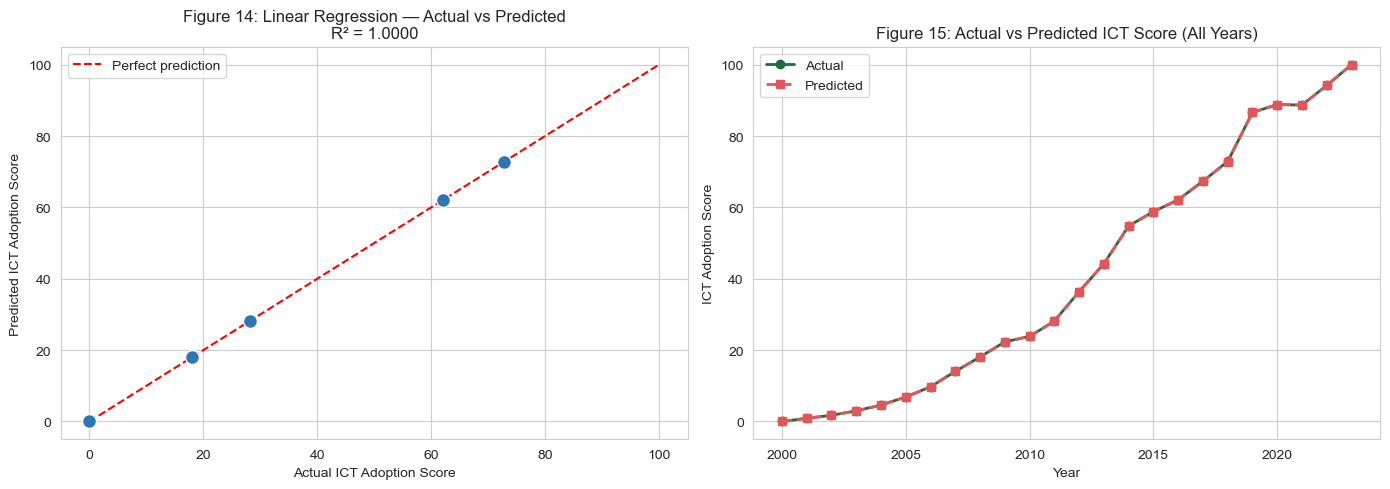

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_ict_test, y_ict_pred, color='#2E75B6', edgecolors='white', s=100, zorder=3)
axes[0].plot([y_ict.min(), y_ict.max()], [y_ict.min(), y_ict.max()], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_title(f'Figure 14: Linear Regression — Actual vs Predicted\nR² = {r2:.4f}')
axes[0].set_xlabel('Actual ICT Adoption Score')
axes[0].set_ylabel('Predicted ICT Adoption Score')
axes[0].legend()

# Full trend with predictions
y_all_pred = lr.predict(X_ict)
axes[1].plot(ict['year'], ict['ict_score'], 'o-', color='#1E6B3C', linewidth=2, label='Actual')
axes[1].plot(ict['year'], y_all_pred, 's--', color='#E15759', linewidth=2, label='Predicted')
axes[1].set_title('Figure 15: Actual vs Predicted ICT Score (All Years)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('ICT Adoption Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/fig14_fig15_lr_results.png', bbox_inches='tight')
plt.show()


##  Decision Tree Classifier

In [16]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt.fit(X_sur_train, y_sur_train)
y_dt_pred = dt.predict(X_sur_test)

dt_acc  = accuracy_score(y_sur_test, y_dt_pred)
dt_prec = precision_score(y_sur_test, y_dt_pred, average='weighted')
dt_rec  = recall_score(y_sur_test, y_dt_pred, average='weighted')
dt_f1   = f1_score(y_sur_test, y_dt_pred, average='weighted')

print('DECISION TREE — RESULTS')
print(f'max_depth         : 4')
print(f'Training samples  : {len(X_sur_train)}')
print(f'Testing samples   : {len(X_sur_test)}')
print()
print(f'Accuracy          : {dt_acc:.4f}  ({dt_acc*100:.1f}%)')
print(f'Precision         : {dt_prec:.4f}')
print(f'Recall            : {dt_rec:.4f}')
print(f'F1 Score          : {dt_f1:.4f}')
print()
print('Per-class report:')
print(classification_report(y_sur_test, y_dt_pred, target_names=le.classes_))

DECISION TREE — RESULTS
max_depth         : 4
Training samples  : 525
Testing samples   : 132

Accuracy          : 0.6212  (62.1%)
Precision         : 0.7195
Recall            : 0.6212
F1 Score          : 0.6203

Per-class report:
              precision    recall  f1-score   support

        High       0.36      0.67      0.47        12
         Low       0.54      0.92      0.68        37
      Medium       0.85      0.48      0.62        83

    accuracy                           0.62       132
   macro avg       0.58      0.69      0.59       132
weighted avg       0.72      0.62      0.62       132



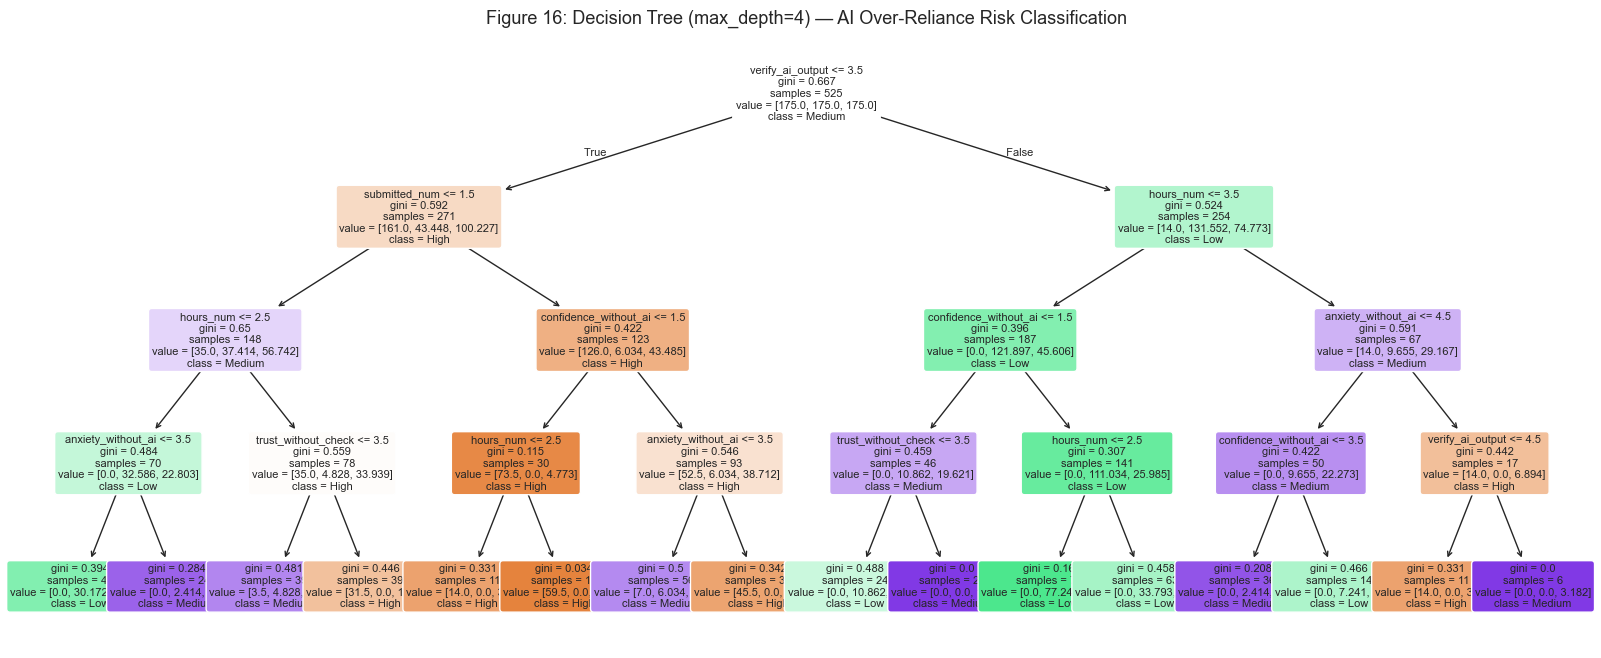

The tree shows the decision rules the model learned.
Each internal node is a test on a feature. Each leaf is a risk class.


In [17]:
# Visualise the Decision Tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=features, class_names=le.classes_,
          filled=True, rounded=True, ax=ax, fontsize=8)
plt.title('Figure 16: Decision Tree (max_depth=4) — AI Over-Reliance Risk Classification', fontsize=13)
plt.savefig('plots/fig16_decision_tree.png', bbox_inches='tight', dpi=120)
plt.show()
print('The tree shows the decision rules the model learned.')
print('Each internal node is a test on a feature. Each leaf is a risk class.')

## K-Nearest Neighbour (KNN)


Best k: 12  (Test Accuracy: 0.8258)


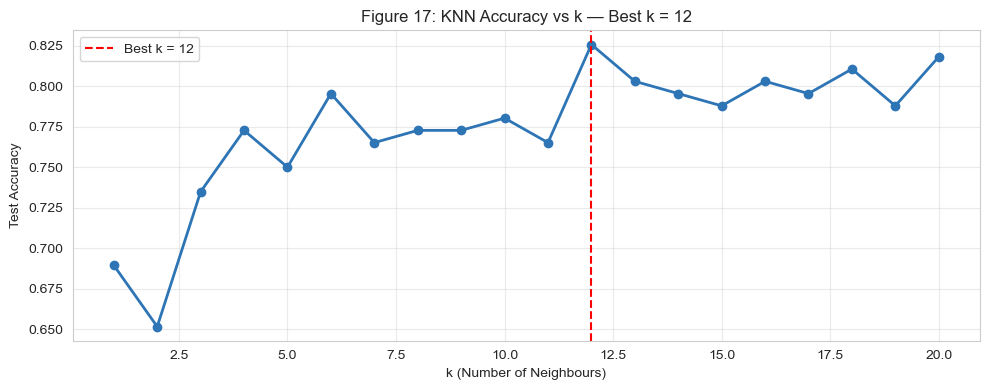

In [18]:
# Tune k from 1 to 20 (StandardScaler applied , required for distance-based models)
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_sur_train_s, y_sur_train)
    k_scores.append(knn.score(X_sur_test_s, y_sur_test))

best_k = k_scores.index(max(k_scores)) + 1
print(f'Best k: {best_k}  (Test Accuracy: {max(k_scores):.4f})')

plt.figure(figsize=(10, 4))
plt.plot(range(1, 21), k_scores, marker='o', color='#2E75B6', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('k (Number of Neighbours)')
plt.ylabel('Test Accuracy')
plt.title(f'Figure 17: KNN Accuracy vs k — Best k = {best_k}')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('plots/fig17_knn_tuning.png', bbox_inches='tight')
plt.show()

In [19]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_sur_train_s, y_sur_train)
y_knn_pred = knn_best.predict(X_sur_test_s)

knn_acc  = accuracy_score(y_sur_test, y_knn_pred)
knn_prec = precision_score(y_sur_test, y_knn_pred, average='weighted')
knn_rec  = recall_score(y_sur_test, y_knn_pred, average='weighted')
knn_f1   = f1_score(y_sur_test, y_knn_pred, average='weighted')

print('KNN — RESULTS')
print(f'Best k            : {best_k}')
print(f'Training samples  : {len(X_sur_train_s)}')
print(f'Testing samples   : {len(X_sur_test_s)}')
print()
print(f'Accuracy          : {knn_acc:.4f}  ({knn_acc*100:.1f}%)')
print(f'Precision         : {knn_prec:.4f}')
print(f'Recall            : {knn_rec:.4f}')
print(f'F1 Score          : {knn_f1:.4f}')
print()
print('Per-class report:')
print(classification_report(y_sur_test, y_knn_pred, target_names=le.classes_))

KNN — RESULTS
Best k            : 12
Training samples  : 525
Testing samples   : 132

Accuracy          : 0.8258  (82.6%)
Precision         : 0.8273
Recall            : 0.8258
F1 Score          : 0.8089

Per-class report:
              precision    recall  f1-score   support

        High       0.75      0.25      0.38        12
         Low       0.90      0.73      0.81        37
      Medium       0.81      0.95      0.87        83

    accuracy                           0.83       132
   macro avg       0.82      0.64      0.68       132
weighted avg       0.83      0.83      0.81       132




## K-Means Clustering

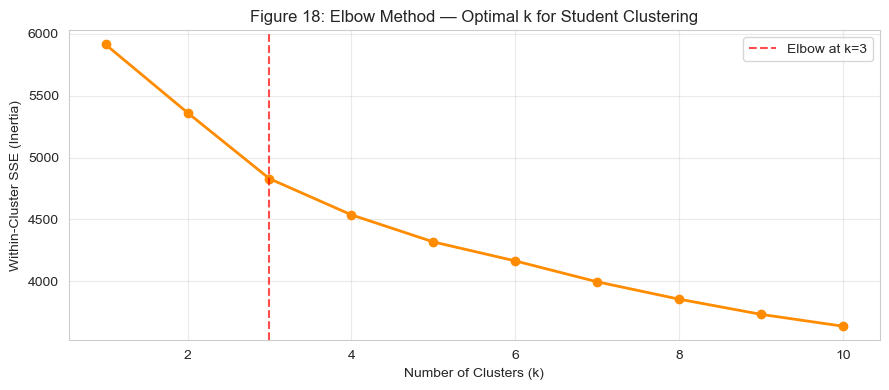

The elbow at k=3 suggests 3 natural student groups.
This aligns with our 3 risk levels: Low, Medium, High.


In [20]:
# Elbow method to find optimal k
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_s)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(range(1, 11), inertias, marker='o', color='darkorange', linewidth=2)
plt.axvline(3, color='red', linestyle='--', alpha=0.7, label='Elbow at k=3')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster SSE (Inertia)')
plt.title('Figure 18: Elbow Method — Optimal k for Student Clustering')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('plots/fig18_elbow.png', bbox_inches='tight')
plt.show()
print('The elbow at k=3 suggests 3 natural student groups.')
print('This aligns with our 3 risk levels: Low, Medium, High.')

K-MEANS CLUSTERING  RESULTS
k (clusters)      : 3
Total samples     : 657
Silhouette Score  : 0.1086  (closer to 1 = better separation)

Cluster sizes:
  Cluster 0: 211 students (32.1%)
  Cluster 1: 151 students (23.0%)
  Cluster 2: 295 students (44.9%)

PCA variance explained: 26.4%


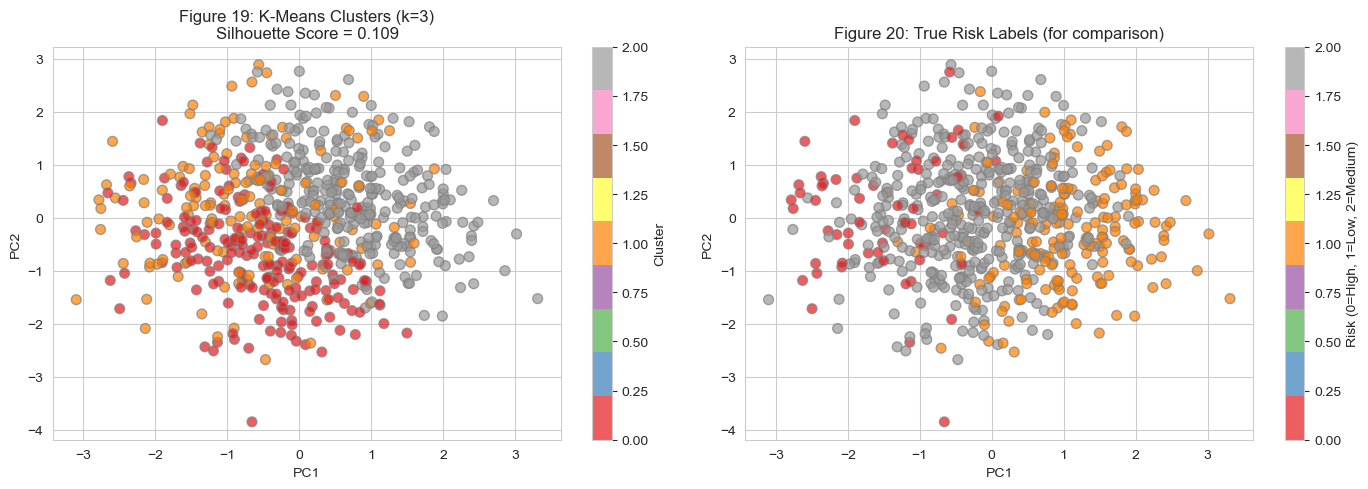

In [21]:
# Train K-Means with k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_clust_s)

sil = silhouette_score(X_clust_s, cluster_labels)
print('K-MEANS CLUSTERING  RESULTS')
print(f'k (clusters)      : 3')
print(f'Total samples     : {len(X_clust_s)}')
print(f'Silhouette Score  : {sil:.4f}  (closer to 1 = better separation)')
print()
print('Cluster sizes:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n} students ({n/len(cluster_labels)*100:.1f}%)')

# PCA for 2D visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust_s)
print(f'\nPCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means clusters
scatter1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels,
    cmap='Set1', alpha=0.7, edgecolors='grey', s=50)
axes[0].set_title(f'Figure 19: K-Means Clusters (k=3)\nSilhouette Score = {sil:.3f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# True risk labels for comparison
risk_enc = le.transform(survey['risk_level'])
scatter2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=risk_enc,
    cmap='Set1', alpha=0.7, edgecolors='grey', s=50)
axes[1].set_title('Figure 20: True Risk Labels (for comparison)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Risk (0=High, 1=Low, 2=Medium)')

plt.tight_layout()
plt.savefig('plots/fig19_fig20_kmeans.png', bbox_inches='tight')
plt.show()


## Model Evaluation and Comparison

###  Confusion Matrices — Decision Tree vs KNN

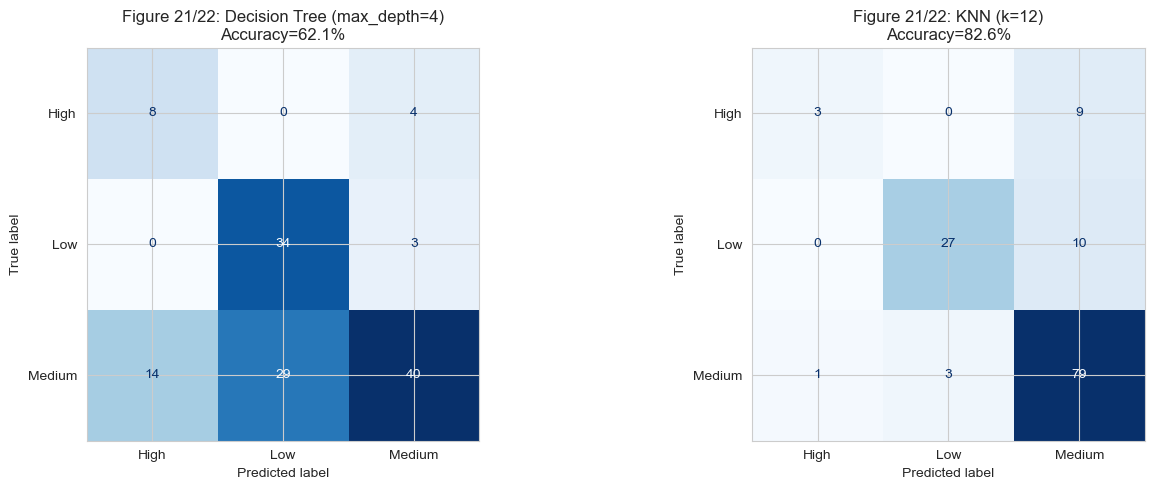

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(
    axes,
    [y_dt_pred, y_knn_pred],
    [f'Decision Tree (max_depth=4)\nAccuracy={dt_acc*100:.1f}%',
     f'KNN (k={best_k})\nAccuracy={knn_acc*100:.1f}%']
):
    cm = confusion_matrix(y_sur_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title('Figure 21/22: ' + title)

plt.tight_layout()
plt.savefig('plots/fig21_fig22_confusion_matrices.png', bbox_inches='tight')
plt.show()

### 10.2 Model Comparison Summary Table

In [27]:
print('MODEL COMPARISON ')

print(f'{"Model":<30} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')

print(f'{"Decision Tree (max_depth=4)":<30} {dt_acc*100:>9.1f}% {dt_prec*100:>9.1f}% {dt_rec*100:>9.1f}% {dt_f1*100:>9.1f}%')
print(f'{f"KNN (k={best_k})":<30} {knn_acc*100:>9.1f}% {knn_prec*100:>9.1f}% {knn_rec*100:>9.1f}% {knn_f1*100:>9.1f}%')
print()
print('REGRESSION MODEL')

print(f'{"Model":<30} {"MAE":>10} {"RMSE":>10} {"R²":>10}')

print(f'{"Linear Regression":<30} {mae:>10.4f} {rmse:>10.4f} {r2:>10.4f}')
print()
print('CLUSTERING MODEL')

print(f'{"Model":<30} {"k":>10} {"Silhouette":>10}')

print(f'{"K-Means":<30} {3:>10} {sil:>10.4f}')

# Feature importance from Decision Tree
print()
print('DECISION TREE — FEATURE IMPORTANCE')

fi = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=False)
for feat, imp in fi.items():
    bar = '|' * int(imp * 50)
    print(f'  {feat:<28}: {imp:.4f}  {bar}')

MODEL COMPARISON 
Model                            Accuracy  Precision     Recall         F1
Decision Tree (max_depth=4)         62.1%      71.9%      62.1%      62.0%
KNN (k=12)                          82.6%      82.7%      82.6%      80.9%

REGRESSION MODEL
Model                                 MAE       RMSE         R²
Linear Regression                  0.0033     0.0035     1.0000

CLUSTERING MODEL
Model                                   k Silhouette
K-Means                                 3     0.1086

DECISION TREE — FEATURE IMPORTANCE
  verify_ai_output            : 0.3081  |||||||||||||||
  hours_num                   : 0.2112  ||||||||||
  anxiety_without_ai          : 0.1545  |||||||
  confidence_without_ai       : 0.1403  |||||||
  submitted_num               : 0.1204  ||||||
  trust_without_check         : 0.0655  |||
  tools_num                   : 0.0000  
  ai_literacy                 : 0.0000  
  guidance_num                : 0.0000  


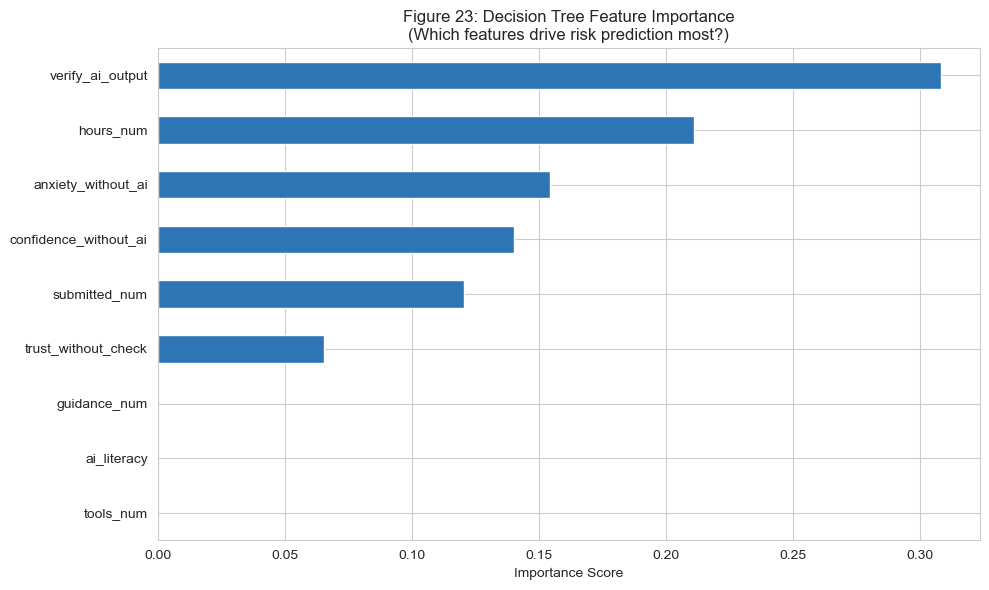

In [24]:
# Feature importance bar chart
fig, ax = plt.subplots(figsize=(10, 6))
fi.sort_values().plot(kind='barh', color='#2E75B6', edgecolor='white', ax=ax)
ax.set_title('Figure 23: Decision Tree Feature Importance\n(Which features drive risk prediction most?)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plots/fig23_feature_importance.png', bbox_inches='tight')
plt.show()

###  Key Findings

1. **ICT adoption in Cameroon grew dramatically** from near zero in 2000 to a score of 100 by 2023, driven primarily by internet access expansion.

2. **The most important predictor of student over-reliance risk** is how often the student verifies AI output before using it. Students who never verify are almost always classified as High risk.

3. **Daily AI usage hours** is the second most important predictor. Students using AI 5 or more hours per day show significantly higher risk.

4. **Over 50% of students fall in the Medium risk category**, suggesting that the majority of Cameroonian university students show some level of over-reliance on AI tools.

5. **Only 25% of students report receiving guidance** on responsible AI use from their university, indicating a significant gap in institutional support.

###  Recommendations

- Universities should introduce **AI literacy programs** to help students understand the limitations of AI tools.
- Lecturers should design assessments that require **critical engagement** with AI outputs rather than direct submission.